In [1]:
# Install PyTorch Geometric (run only once in Colab)
!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("✅ Imports successful")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Imports successful


In [18]:
import glob

dataset_path = "/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset"

# Collect separately
accident_files = glob.glob(dataset_path + "/**/*accident/**/*.txt", recursive=True)
normal_files = glob.glob(dataset_path + "/**/*normal/**/*.txt", recursive=True)

print("Accident files:", len(accident_files))
print("Normal files:", len(normal_files))

# Combine
all_files = accident_files + normal_files

# Labels
labels = [1]*len(accident_files) + [0]*len(normal_files)

print("\nTotal files:", len(all_files))
print("Accident:", labels.count(1))
print("Normal:", labels.count(0))

Accident files: 664
Normal files: 994

Total files: 1658
Accident: 664
Normal: 994


In [19]:
from collections import Counter

folder_counts = Counter()

for f in all_files:
    folder = f.split("/")[-3]   # folder name (type1_subtype1_accident etc.)
    folder_counts[folder] += 1

print(folder_counts)

Counter({'type1_subtype1_normal': 694, 'type1_subtype1_accident': 424, 'type1_subtype2_normal': 300, 'type1_subtype2_accident': 240})


In [20]:
for i in range(10):
    print(all_files[i], "→", labels[i])

for i in range(len(all_files)):
    if "normal" in all_files[i].lower():
        print(all_files[i], "→", labels[i])
        break

/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town07_type001_subtype0001_scenario00031/Town07_type001_subtype0001_scenario00031_013.txt → 1
/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town07_type001_subtype0001_scenario00031/Town07_type001_subtype0001_scenario00031_018.txt → 1
/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town07_type001_subtype0001_scenario00031/Town07_type001_subtype0001_scenario00031_023.txt → 1
/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town07_type001_subtype0001_scenario00031/Town07_type001_subtype0001_scenario00031_038.txt → 1
/kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town07_type001_subtype0001_scenario00031/Town07_type001_subtype0001_scenario00031_02

In [21]:
from torch.utils.data import Dataset
from sklearn.neighbors import kneighbors_graph

class DeepAccidentDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __len__(self):
        return len(self.file_list)

    def normalize(self, x):
        mean = x.mean(axis=0)
        std = x.std(axis=0) + 1e-6
        return (x - mean) / std

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        label = self.labels[idx]

        cols = ['type','x','y','z','len','wid','hgt','yaw','vx','vy','id','frame','active']
        df = pd.read_csv(file_path, sep=r'\s+', names=cols, skiprows=2)

        # Use 4 features
        x = df[['x','y','vx','vy']].values

        # Normalize
        x = self.normalize(x)

        x = torch.tensor(x, dtype=torch.float)

        # KNN graph (IMPORTANT FIX)
        if len(x) > 1:
            A = kneighbors_graph(x.numpy(), n_neighbors=min(5, len(x)), mode='connectivity')
            edge_index = torch.tensor(np.array(A.nonzero()), dtype=torch.long)
        else:
            edge_index = torch.empty((2,0), dtype=torch.long)

        y = torch.tensor([label], dtype=torch.long)

        return Data(x=x, edge_index=edge_index, y=y)

In [22]:
from sklearn.model_selection import train_test_split

# First split: train vs temp
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

# Second split: val vs test
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

train_dataset = DeepAccidentDataset(train_files, train_labels)
val_dataset   = DeepAccidentDataset(val_files, val_labels)
test_dataset  = DeepAccidentDataset(test_files, test_labels)

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)

Train: 1160
Val: 249
Test: 249


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.nn import BatchNorm1d

class AccidentGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(4, 64)
        self.bn1 = BatchNorm1d(64)

        self.conv2 = GCNConv(64, 64)
        self.bn2 = BatchNorm1d(64)

        self.lin = torch.nn.Linear(64, 2)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)

        x = global_mean_pool(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)

        return self.lin(x)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=labels
)

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            labels_list.extend(data.y.cpu().numpy())

    acc = accuracy_score(labels_list, preds)
    return acc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AccidentGNN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

num_epochs = 30

best_val_acc = 0
best_epoch = 0
patience = 10
counter = 0

train_losses = []
val_accuracies = []

print("🚀 Training started...\n")

for epoch in range(num_epochs):

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_acc = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ✅ Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print(f"   🔥 New Best Model Saved (Val Acc: {best_val_acc:.4f})")

    else:
        counter += 1

    # Early stopping
    if counter >= patience:
        print("\n⛔ Early stopping triggered")
        break

# Load best model
model.load_state_dict(torch.load("best_model.pth"))

test_acc = evaluate(model, test_loader, device)

print("\n✅ BEST VALIDATION ACCURACY:", best_val_acc)
print("📌 BEST MODEL AT EPOCH:", best_epoch)
print("🎯 FINAL TEST ACCURACY:", test_acc)

🚀 Training started...

Epoch 01 | Loss: 0.6936 | Val Acc: 0.6345
   🔥 New Best Model Saved (Val Acc: 0.6345)
Epoch 02 | Loss: 0.6674 | Val Acc: 0.6426
   🔥 New Best Model Saved (Val Acc: 0.6426)
Epoch 03 | Loss: 0.6630 | Val Acc: 0.6586
   🔥 New Best Model Saved (Val Acc: 0.6586)
Epoch 04 | Loss: 0.6525 | Val Acc: 0.6265
Epoch 05 | Loss: 0.6471 | Val Acc: 0.6265
Epoch 06 | Loss: 0.6436 | Val Acc: 0.6627
   🔥 New Best Model Saved (Val Acc: 0.6627)
Epoch 07 | Loss: 0.6286 | Val Acc: 0.6667
   🔥 New Best Model Saved (Val Acc: 0.6667)
Epoch 08 | Loss: 0.6283 | Val Acc: 0.6506
Epoch 09 | Loss: 0.6265 | Val Acc: 0.6627
Epoch 10 | Loss: 0.6109 | Val Acc: 0.6787
   🔥 New Best Model Saved (Val Acc: 0.6787)
Epoch 11 | Loss: 0.6052 | Val Acc: 0.6627
Epoch 12 | Loss: 0.6050 | Val Acc: 0.6024
Epoch 13 | Loss: 0.5969 | Val Acc: 0.6586
Epoch 14 | Loss: 0.5930 | Val Acc: 0.6546
Epoch 15 | Loss: 0.5904 | Val Acc: 0.6787
Epoch 16 | Loss: 0.5883 | Val Acc: 0.6586
Epoch 17 | Loss: 0.5787 | Val Acc: 0.7028

**PHASE 2 [GAT]**


In [28]:
from torch.utils.data import Dataset
from sklearn.neighbors import kneighbors_graph

class DeepAccidentDatasetEnhanced(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __len__(self):
        return len(self.file_list)

    def normalize(self, x):
        mean = x.mean(axis=0)
        std = x.std(axis=0) + 1e-6
        return (x - mean) / std

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        label = self.labels[idx]

        cols = ['type','x','y','z','len','wid','hgt','yaw','vx','vy','id','frame','active']
        df = pd.read_csv(file_path, sep=r'\s+', names=cols, skiprows=2)

        features = []

        for _, row in df.iterrows():
            x, y = row['x'], row['y']
            vx, vy = row['vx'], row['vy']

            # Derived features
            speed = np.sqrt(vx**2 + vy**2)
            heading = np.arctan2(vy, vx)

            # Type encoding
            t = row['type']
            is_car = 1 if t == 1 else 0
            is_truck = 1 if t == 2 else 0
            is_ped = 1 if t == 3 else 0

            # Dimensions
            length = row['len']
            width = row['wid']

            features.append([
                x, y, vx, vy,
                speed, heading,
                is_car, is_truck, is_ped,
                length, width
            ])

        x = np.array(features)
        x = self.normalize(x)
        x = torch.tensor(x, dtype=torch.float)

        # KNN Graph
        if len(x) > 1:
            A = kneighbors_graph(x.numpy(), n_neighbors=min(5, len(x)), mode='connectivity')
            edge_index = torch.tensor(np.array(A.nonzero()), dtype=torch.long)
        else:
            edge_index = torch.empty((2,0), dtype=torch.long)

        y = torch.tensor([label], dtype=torch.long)

        return Data(x=x, edge_index=edge_index, y=y)

In [29]:
train_dataset = DeepAccidentDatasetEnhanced(train_files, train_labels)
val_dataset   = DeepAccidentDatasetEnhanced(val_files, val_labels)
test_dataset  = DeepAccidentDatasetEnhanced(test_files, test_labels)

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)

In [31]:
from torch_geometric.nn import GATConv

class EnhancedGAT(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(11, 64, heads=4, dropout=0.3)
        self.gat2 = GATConv(64*4, 64, heads=1, dropout=0.3)

        self.lin = torch.nn.Linear(64, 2)

    def forward(self, x, edge_index, batch):
        x = self.gat1(x, edge_index)
        x = F.elu(x)

        x = self.gat2(x, edge_index)

        x = global_mean_pool(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)

        return self.lin(x)

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=labels
)

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EnhancedGAT().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

num_epochs = 50

best_val_acc = 0
best_epoch = 0
patience = 10
counter = 0

print("🚀 Phase 2 Training started...\n")

for epoch in range(num_epochs):

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_acc = evaluate(model, val_loader, device)

    print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        counter = 0
        torch.save(model.state_dict(), "best_gat_model.pth")
        print(f"🔥 New Best Model Saved (Val Acc: {best_val_acc:.4f})")
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping")
        break

model.load_state_dict(torch.load("best_gat_model.pth"))

test_acc = evaluate(model, test_loader, device)

print("\n✅ PHASE 2 RESULTS")
print("Best Validation Accuracy:", best_val_acc)
print("Best Epoch:", best_epoch)
print("Final Test Accuracy:", test_acc)

🚀 Phase 2 Training started...

Epoch 01 | Loss: 0.6618 | Val Acc: 0.6466
🔥 New Best Model Saved (Val Acc: 0.6466)
Epoch 02 | Loss: 0.6154 | Val Acc: 0.6627
🔥 New Best Model Saved (Val Acc: 0.6627)
Epoch 03 | Loss: 0.5978 | Val Acc: 0.6466
Epoch 04 | Loss: 0.5809 | Val Acc: 0.6506
Epoch 05 | Loss: 0.5854 | Val Acc: 0.6586
Epoch 06 | Loss: 0.5776 | Val Acc: 0.6747
🔥 New Best Model Saved (Val Acc: 0.6747)
Epoch 07 | Loss: 0.5611 | Val Acc: 0.6867
🔥 New Best Model Saved (Val Acc: 0.6867)
Epoch 08 | Loss: 0.5603 | Val Acc: 0.6948
🔥 New Best Model Saved (Val Acc: 0.6948)
Epoch 09 | Loss: 0.5679 | Val Acc: 0.6948
Epoch 10 | Loss: 0.5573 | Val Acc: 0.6948
Epoch 11 | Loss: 0.5445 | Val Acc: 0.6988
🔥 New Best Model Saved (Val Acc: 0.6988)
Epoch 12 | Loss: 0.5332 | Val Acc: 0.6586
Epoch 13 | Loss: 0.5162 | Val Acc: 0.6867
Epoch 14 | Loss: 0.5295 | Val Acc: 0.6908
Epoch 15 | Loss: 0.4981 | Val Acc: 0.7068
🔥 New Best Model Saved (Val Acc: 0.7068)
Epoch 16 | Loss: 0.5224 | Val Acc: 0.7028
Epoch 17 |

**COUNTERFACTUAL PART**

**correct final part**


📁 Sample Index: 222
📄 File: /kaggle/input/datasets/gopikavelusamy/minireview-dataset/deepaccident_final_dataset/type1_subtype1_accident/Town03_type001_subtype0001_scenario00024/Town03_type001_subtype0001_scenario00024_003.txt

📄 RAW DATA (first 5 rows)
  type          x          y   vx   vy
0  car -75.477804   6.768775  0.0  0.0
1  car -76.016994 -72.298440  0.0  0.0
2  car -75.366575 -67.001016  0.0  0.0
3  car -75.477782 -62.314813  0.0  0.0
4  car -76.017016  -3.214860  0.0  0.0

🎯 ACTUAL vs PREDICTED
Actual : Accident
Pred   : Accident
Prob   : 0.701


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


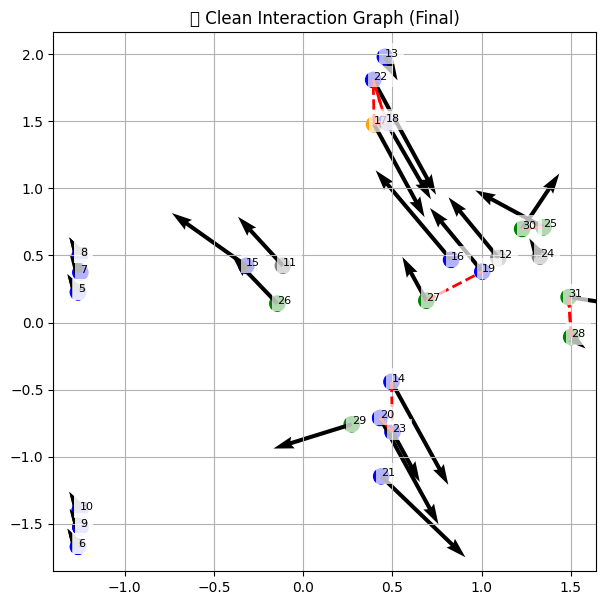

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


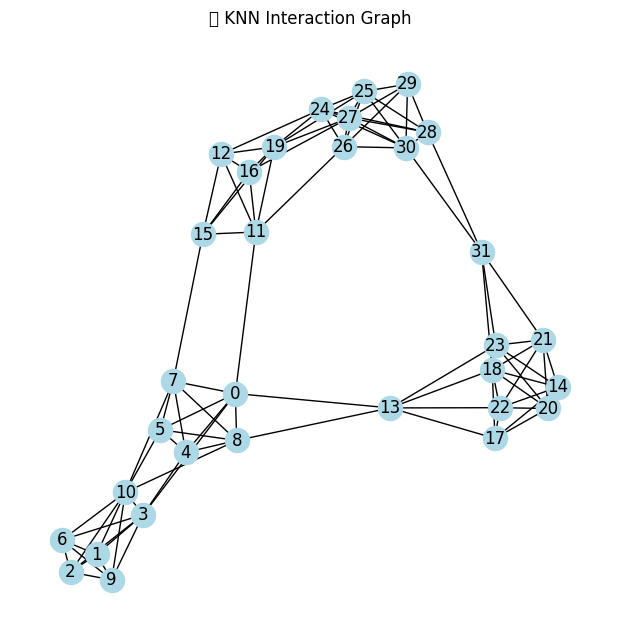


🔧 COUNTERFACTUAL ANALYSIS
[Vehicle 0] speed → Pred: 1, Prob: 0.662
[Vehicle 0] brake → Pred: 0, Prob: 0.412
[Vehicle 0] Lane → Pred: 1, Prob: 0.686
[Vehicle 1] speed → Pred: 1, Prob: 0.625
[Vehicle 1] brake → Pred: 0, Prob: 0.461
[Vehicle 1] Lane → Pred: 1, Prob: 0.691
[Vehicle 2] speed → Pred: 1, Prob: 0.647
[Vehicle 2] brake → Pred: 0, Prob: 0.458
[Vehicle 2] Lane → Pred: 1, Prob: 0.694
[Vehicle 3] speed → Pred: 1, Prob: 0.658
[Vehicle 3] brake → Pred: 0, Prob: 0.46
[Vehicle 3] Lane → Pred: 1, Prob: 0.694
[Vehicle 4] speed → Pred: 1, Prob: 0.646
[Vehicle 4] brake → Pred: 0, Prob: 0.428
[Vehicle 4] Lane → Pred: 1, Prob: 0.676
[Vehicle 5] speed → Pred: 1, Prob: 0.637
[Vehicle 5] brake → Pred: 0, Prob: 0.471
[Vehicle 5] Lane → Pred: 1, Prob: 0.68
[Vehicle 6] speed → Pred: 1, Prob: 0.62
[Vehicle 6] brake → Pred: 0, Prob: 0.489
[Vehicle 6] Lane → Pred: 1, Prob: 0.703
[Vehicle 7] speed → Pred: 1, Prob: 0.643
[Vehicle 7] brake → Pred: 0, Prob: 0.46
[Vehicle 7] Lane → Pred: 1, Prob: 0.682
[

In [78]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import copy
from sklearn.metrics import pairwise_distances

# ---------------- SAMPLE ----------------
idx = random.randint(0, len(test_dataset)-1)
sample = test_dataset[idx]
file_path = test_files[idx]

print("\n==============================")
print("📁 Sample Index:", idx)
print("📄 File:", file_path)

# ---------------- LOAD RAW DATA ----------------
cols = ['type','x','y','z','len','wid','hgt','yaw','vx','vy','id','frame','active']
df = pd.read_csv(file_path, sep=r'\s+', names=cols, skiprows=2)

print("\n📄 RAW DATA (first 5 rows)")
print(df[['type','x','y','vx','vy']].head())

# ---------------- ACTUAL vs PRED ----------------
actual = sample.y.item()
pred, prob = cf.predict(sample)

print("\n🎯 ACTUAL vs PREDICTED")
print("Actual :", "Accident" if actual else "Normal")
print("Pred   :", "Accident" if pred else "Normal")
print("Prob   :", round(prob,3))

# ---------------- TTC VISUALIZATION ----------------
from sklearn.metrics import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt

def visualize_final_clean(sample, df):

    x = sample.x.cpu().numpy()

    pos_x = x[:,0]
    pos_y = x[:,1]
    vx = x[:,2]
    vy = x[:,3]

    # -------- VEHICLE COLORS --------
    colors = []
    for t in df['type']:
        if t == 'car':
            colors.append('blue')
        elif t == 'truck':
            colors.append('orange')
        elif t == 'pedestrian':
            colors.append('green')
        else:
            colors.append('gray')

    plt.figure(figsize=(7,7))

    # nodes
    plt.scatter(pos_x, pos_y, c=colors, s=120)

    # velocity arrows
    plt.quiver(pos_x, pos_y, vx, vy, color='black', scale=10)

    # labels
    for i in range(len(pos_x)):
        plt.text(
            pos_x[i], pos_y[i],
            str(i),
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    # -------- CLEAN INTERACTION LOGIC --------
    coords = np.column_stack((pos_x, pos_y))
    dist_matrix = pairwise_distances(coords)

    k = 2          # only nearest neighbors
    threshold = 2  # distance control

    for i in range(len(x)):

        nearest = np.argsort(dist_matrix[i])[1:k+1]

        for j in nearest:

            dist = dist_matrix[i][j]

            if dist < threshold:

                dx = pos_x[j] - pos_x[i]
                dy = pos_y[j] - pos_y[i]

                dvx = vx[j] - vx[i]
                dvy = vy[j] - vy[i]

                # relative motion
                dot = dx * dvx + dy * dvy

                if dot < 0:  # moving towards each other

                    # optional TTC coloring
                    rel_speed = np.sqrt(dvx**2 + dvy**2)

                    if rel_speed > 0.1:
                        ttc = dist / rel_speed

                        if ttc < 2:
                            color = 'red'
                        elif ttc < 5:
                            color = 'orange'
                        else:
                            continue

                        plt.plot(
                            [pos_x[i], pos_x[j]],
                            [pos_y[i], pos_y[j]],
                            linestyle='--',
                            color=color,
                            linewidth=2
                        )

    plt.title("🚗 Clean Interaction Graph (Final)")
    plt.grid()
    plt.show()
visualize_final_clean(sample, df)

# ---------------- KNN GRAPH ----------------
def visualize_knn(sample):
    edge_index = sample.edge_index.cpu().numpy()

    G = nx.Graph()
    for i in range(sample.x.shape[0]):
        G.add_node(i)

    for i in range(edge_index.shape[1]):
        G.add_edge(int(edge_index[0][i]), int(edge_index[1][i]))

    plt.figure(figsize=(6,6))
    nx.draw(G, with_labels=True, node_color='lightblue')
    plt.title("🔗 KNN Interaction Graph")
    plt.show()

visualize_knn(sample)

# ---------------- COUNTERFACTUAL ----------------
print("\n🔧 COUNTERFACTUAL ANALYSIS")

causal = []
original_pred, original_prob = cf.predict(sample)

for i in range(sample.x.shape[0]):

    for mode in ["speed", "brake", "lane"]:

        d = copy.deepcopy(sample)

        vx = d.x[i,2]
        vy = d.x[i,3]

        if mode == "speed":
            vx *= 0.8
            vy *= 0.8

        elif mode == "brake":
            vx -= 2
            vy -= 2

        elif mode == "lane":
            d.x[i,1] += 3
            p, pr = cf.predict(d)
            prob_drop = original_prob - pr

            print(f"[Vehicle {i}] Lane → Pred: {p}, Prob: {round(pr,3)}")

            if (p == 0 and prob_drop > 0.3) or (prob_drop > 0.4):
                causal.append(i)

            continue

        d.x[i,2], d.x[i,3] = vx, vy
        d.x[i,4] = torch.sqrt(vx**2 + vy**2)
        d.x[i,5] = torch.atan2(vy, vx)

        p, pr = cf.predict(d)
        prob_drop = original_prob - pr

        print(f"[Vehicle {i}] {mode} → Pred: {p}, Prob: {round(pr,3)}")

        if (p == 0 and prob_drop > 0.3) or (prob_drop > 0.4):
            causal.append(i)

# ---------------- TTC FILTER ----------------
x = sample.x.cpu().numpy()
coords = np.column_stack((x[:,0], x[:,1]))
dist_matrix = pairwise_distances(coords)

final_causal = []

for i in causal:
    for j in range(len(x)):

        if i == j:
            continue

        dist = dist_matrix[i][j]

        if dist < 3:

            dx = x[j,0] - x[i,0]
            dy = x[j,1] - x[i,1]

            dvx = x[j,2] - x[i,2]
            dvy = x[j,3] - x[i,3]

            rel_speed = np.sqrt(dvx**2 + dvy**2)

            if rel_speed > 0.1:
                dot = dx * dvx + dy * dvy

                if dot < 0:
                    ttc = dist / rel_speed

                    if ttc < 5:
                        final_causal.append(i)
                        break

print("\n🔥 FINAL CAUSAL VEHICLES:", list(set(final_causal)))